# Scientific NER — Named Entity Recognition for Scientific Text

## Goal
Extract domain-specific entities from scientific papers.
General NER detects people, places, organizations.
Scientific NER detects methods, datasets, metrics, and models.

## Approach
Rule-based NER using pattern matching.
No pretrained model needed — patterns capture scientific vocabulary.

## Key Questions
- What methods are mentioned in the paper?
- What datasets were used?
- What metrics were reported?
- What models were compared?

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

## 1. Load Paper Text

In [2]:
import PyPDF2

def load_pdf(path: str) -> str:
    text = ""
    with open(path, "rb") as f:
        reader = PyPDF2.PdfReader(f)
        for page in reader.pages:
            extracted = page.extract_text()
            if extracted:
                text += extracted + "\n"
    return text

text = load_pdf("../data/raw/paper.pdf")
print(f"Loaded: {len(text.split())} words")

Loaded: 5998 words


## 2. Define Scientific Entity Patterns

In [5]:
# Scientific NER patterns
entity_patterns = {
    "MODEL": [
        r'\bTransformer\b',
        r'\bBERT\b',
        r'\bGPT\b',
        r'\bLSTM\b',
        r'\bRNN\b',
        r'\bCNN\b',
        r'\bEncoder[-\s]Decoder\b',
        r'\bMulti[-\s]Head Attention\b',
        r'\bSelf[-\s]Attention\b',
        r'\bFeed[-\s]Forward\b',
    ],
    "METRIC": [
        r'\bBLEU\b',
        r'\bperplexity\b',
        r'\baccuracy\b',
        r'\bF1\b',
        r'\bROUGE\b',
        r'\bPrecision\b',
        r'\bRecall\b',
        r'\bMSE\b',
        r'\bMAE\b',
    ],
    "DATASET": [
        r'\bWMT\b',
        r'\bImageNet\b',
        r'\bSQuAD\b',
        r'\bGLUE\b',
        r'\bPTB\b',
        r'\bNewsTest\b',
        r'\bEnglish[-\s]German\b',
        r'\bEnglish[-\s]French\b',
    ],
    "METHOD": [
        r'\battention mechanism\b',
        r'\bdropout\b',
        r'\bbatch normalization\b',
        r'\blayer normalization\b',
        r'\bbackpropagation\b',
        r'\bgradient descent\b',
        r'\badam optimizer\b',
        r'\bbeam search\b',
        r'\bpositional encoding\b',
    ]
}

def extract_entities(text: str, patterns: dict) -> dict:
    """Extract scientific entities using regex patterns."""
    results = {}
    for entity_type, pattern_list in patterns.items():
        found = []
        for pattern in pattern_list:
            matches = re.findall(pattern, text, re.IGNORECASE)
            found.extend(matches)
        results[entity_type] = Counter(found)
    return results

entities = extract_entities(text, entity_patterns)

print("Scientific Entities Found:")
for entity_type, counts in entities.items():
    print(f"\n{entity_type}:")
    for entity, count in counts.most_common(5):
        print(f"  {entity:<30} {count:>3} times")

Scientific Entities Found:

MODEL:
  Transformer                     26 times
  self-attention                  20 times
  encoder-decoder                  6 times
  Multi-Head Attention             4 times
  feed-forward                     4 times

METRIC:
  BLEU                            10 times
  perplexity                       1 times
  accuracy                         1 times
  F1                               1 times
  precision                        1 times

DATASET:
  WMT                              8 times
  English-French                   2 times
  English-German                   1 times

METHOD:
  attention mechanism              5 times
  dropout                          5 times
  Dropout                          2 times
  layer normalization              2 times
  beam search                      2 times


## 3. Visualize Entity Distribution

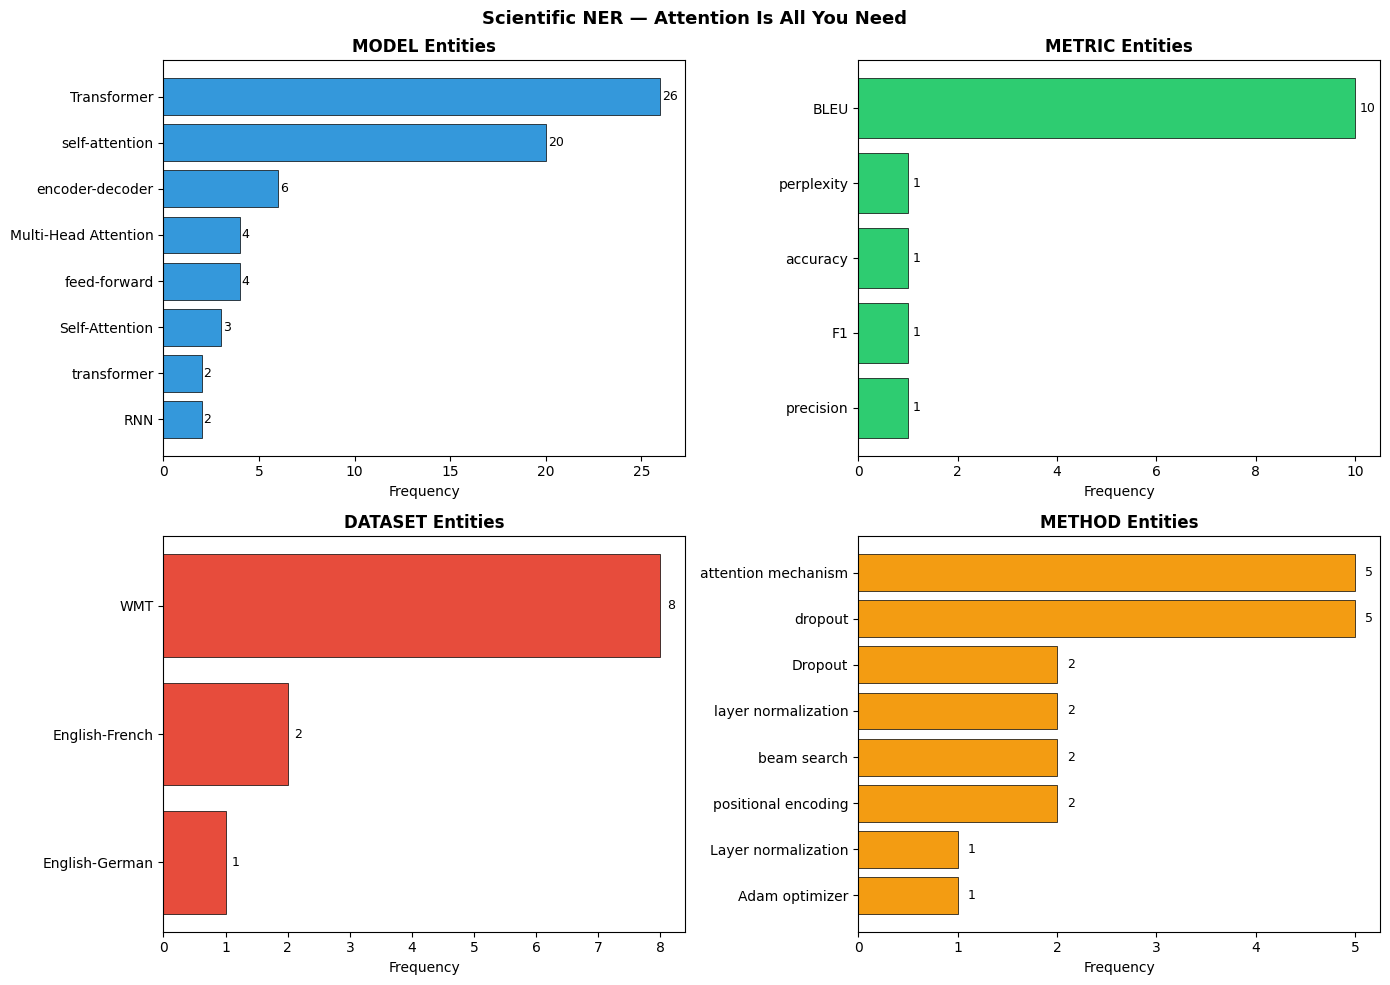

Total entities found: 120


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ["#3498db", "#2ecc71", "#e74c3c", "#f39c12"]

for idx, (entity_type, counts) in enumerate(entities.items()):
    if not counts:
        continue
    
    top_entities = counts.most_common(8)
    names = [e[0][:20] for e in top_entities]
    values = [e[1] for e in top_entities]
    
    bars = axes[idx].barh(names[::-1], values[::-1], 
                         color=colors[idx], edgecolor="black", linewidth=0.5)
    axes[idx].set_title(f"{entity_type} Entities", fontsize=12, fontweight="bold")
    axes[idx].set_xlabel("Frequency")
    
    for bar, val in zip(bars, values[::-1]):
        axes[idx].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                      str(val), va="center", fontsize=9)

plt.suptitle("Scientific NER — Attention Is All You Need",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("scientific_ner.png", dpi=150)
plt.show()

total = sum(sum(c.values()) for c in entities.values())
print(f"Total entities found: {total}")

## 4. Key Observations

| Entity Type | Top Entity | Count | Insight |
|-------------|-----------|-------|---------|
| MODEL | Transformer | 26 | Core subject of the paper |
| MODEL | Self-attention | 20 | Main mechanism |
| METRIC | BLEU | 10 | Translation quality metric |
| DATASET | WMT | 8 | Standard translation benchmark |
| METHOD | Attention mechanism | 5 | Key contribution |

## Key Insight
Rule-based NER is interpretable and requires no training data.
It works well for domain-specific vocabulary that rarely changes.

Limitation: case sensitivity causes duplicates ("dropout" vs "Dropout").
A production system would normalize entities before counting.

## What This Enables
Given any scientific paper, we can automatically answer:
- What models were used or proposed?
- What metrics were reported?
- What datasets were used?
- What methods were applied?

## Next
Find semantically similar papers using embeddings.
-> 03_paper_similarity.ipynb